<a href="https://colab.research.google.com/github/hye0-n0/AI_finance/blob/main/HW5_PartC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

## **Part C: Financial Planning for the Beloved Ones**
부모님 은퇴자산 전략이므로 한글로 작성

In [ ]:
# 자산 기대 수익률 및 공분산 (한국 시장 기준)
mean_returns = np.array([0.05, 0.025, 0.020])
cov_matrix = np.diag([0.15**2, 0.03**2, 0.002**2])

# 투자 설정
initial_wealth = 370000000
initial_salary = 100000000
growth_rate = 0.01
saving_rate = 0.10
years = 10
n_sim = 1000

# 국민연금: 65세부터 월 100만 원 수령 가정 → 10년치 현재가치 반영
monthly_pension = 1000000
annual_pension = monthly_pension * 12
total_pension_income = annual_pension * 10  # 10년 수령

# 총 저축 계산
salary = initial_salary
total_savings = 0
for _ in range(years):
    total_savings += salary * saving_rate
    salary *= (1 + growth_rate)
total_wealth = initial_wealth + total_savings

# 목표 자산 (은퇴 후 7억 + 국민연금 가정 시 보완된 기준)
adjusted_target_wealth = 700000000 - total_pension_income

### Efficient Frontier (Buy-and-Hold, Shorting 허용/금지)
- buy-and-hold 전략: 초기에 비율을 정하고 10년 동안 그대로 보유
- 필요한 것:
  - 각 자산군의 평균 수익률 (mean), 분산 (variance) 추정
  - 이를 기반으로 Efficient Frontier (효율적 투자선) 그림
- 조건: shorting 금지 (모든 비중 ≥ 0)

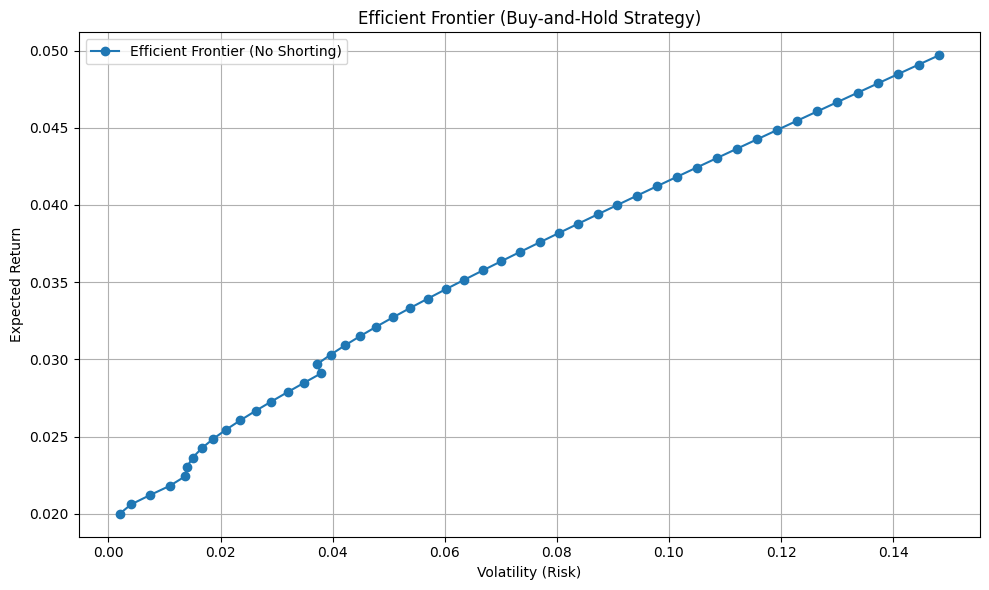

In [ ]:
# 효율적 프론티어 계산
def portfolio_return(weights, returns):
    return np.dot(weights, returns)

def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

target_returns = np.linspace(0.0, 0.06, 100)
vols, rets, weights_list, success_probs = [], [], [], []

for target in target_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mean_returns) - target}
    )
    bounds = [(0, 1)] * len(mean_returns)

    result = minimize(portfolio_variance, [1/len(mean_returns)]*len(mean_returns),
                      args=(cov_matrix,), method='SLSQP',
                      bounds=bounds, constraints=constraints)

    if result.success:
        weights = result.x
        weights_list.append(weights)
        vol = np.sqrt(result.fun)
        vols.append(vol)
        rets.append(target)

        # 시뮬레이션 (Buy-and-Hold)
        sim_final_wealth = []
        for _ in range(n_sim):
            simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, years)
            wealth = total_wealth
            for r in simulated_returns:
                wealth *= (1 + np.dot(weights, r))
            sim_final_wealth.append(wealth)

        sim_final_wealth = np.array(sim_final_wealth)
        prob_success = np.mean(sim_final_wealth >= adjusted_target_wealth)
        success_probs.append(prob_success)

# Efficient Frontier 시각화
plt.figure(figsize=(10, 6))
plt.plot(vols, rets, label='Efficient Frontier (No Shorting)', marker='o')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Buy-and-Hold Strategy)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Stocks    0.134225
Bonds     0.406774
Cash      0.459001
dtype: float64


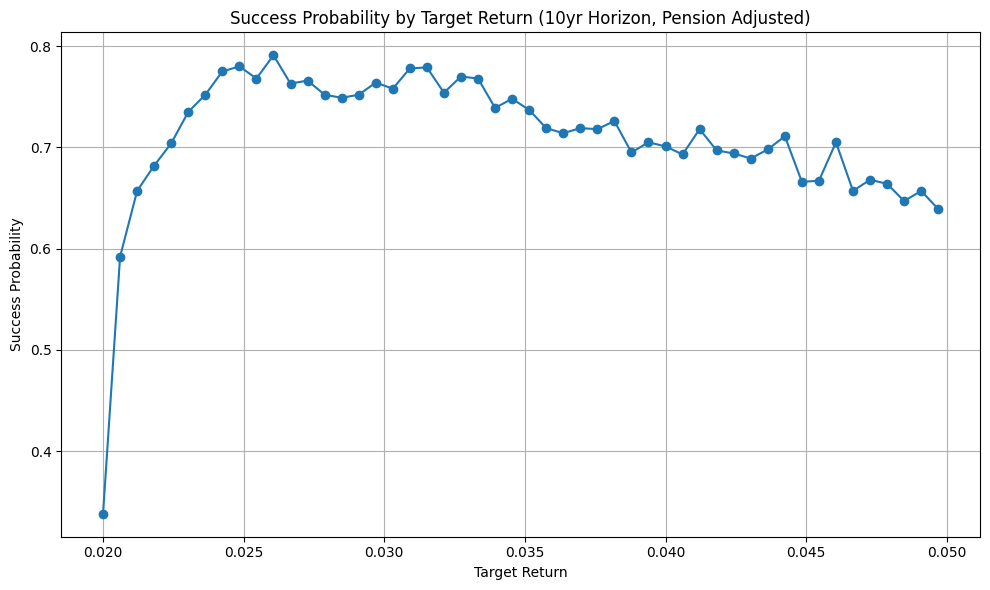

In [ ]:
# 대체 위험 지표 계산 (최고 기대 성공 확률 조합 기준)
best_idx = np.argmax(success_probs)
best_weights = weights_list[best_idx]

# 1. 해당 포트폴리오 자산 비중 출력
best_allocation = pd.Series(best_weights, index=['Stocks', 'Bonds', 'Cash'])
print(best_allocation)

# 2. 목표 수익률별 성공 확률 테이블 생성
df_success_prob = pd.DataFrame({
    'Target Return': rets,
    'Volatility': vols,
    'Success Probability': success_probs
})

# 3. 성공 확률 시각화
plt.figure(figsize=(10, 6))
plt.plot(rets, success_probs, marker='o')
plt.xlabel('Target Return')
plt.ylabel('Success Probability')
plt.title('Success Probability by Target Return (10yr Horizon, Pension Adjusted)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 성공 확률 기준으로 내림차순 정렬
df_success_prob_sorted = df_success_prob.sort_values(by='Success Probability', ascending=False).reset_index(drop=True)
df_success_prob_sorted

,Target Return,Volatility,Success Probability
0,0.026061,0.023561,0.791
1,0.024848,0.018674,0.780
2,0.031515,0.044946,0.779
3,0.030909,0.042212,0.778
4,0.024242,0.016641,0.775
5,0.032727,0.050786,0.770
6,0.033333,0.053852,0.768
7,0.025455,0.021011,0.768
8,0.027273,0.029072,0.766
9,0.029697,0.037247,0.764


In [ ]:
# 목표 수익률 0.026061에 해당하는 비중 찾기 (근사 탐색)
target_val = 0.026061
matching_index = df_success_prob.loc[(df_success_prob['Target Return'] - target_val).abs().idxmin()].name

# 해당 인덱스의 비중 추출
selected_weights = weights_list[matching_index]
print(selected_weights)

# 해당 비중으로 재시뮬레이션 후 위험 지표 계산
sim_final_wealth_best = []
for _ in range(n_sim):
    simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, years)
    wealth = total_wealth
    for r in simulated_returns:
        wealth *= (1 + np.dot(selected_weights, r))
    sim_final_wealth_best.append(wealth)

sim_final_wealth_best = np.array(sim_final_wealth_best)
VaR_5 = np.percentile(sim_final_wealth_best, 5)
CVaR_5 = sim_final_wealth_best[sim_final_wealth_best <= VaR_5].mean()
mean_wealth = sim_final_wealth_best.mean()
std_wealth = sim_final_wealth_best.std()

# 결과 정리
risk_measures = pd.DataFrame({
    "Measure": ["Expected Final Wealth", "Standard Deviation", "Value at Risk (5%)", "Conditional VaR (5%)"],
    "KRW Value": [mean_wealth, std_wealth, VaR_5, CVaR_5]
})

risk_measures

[0.13422451 0.40677412 0.45900137]


,Measure,KRW Value
0,Expected Final Wealth,6.132193e+08
1,Standard Deviation,4.505700e+07
2,Value at Risk (5%),5.416077e+08
3,Conditional VaR (5%),5.255363e+08


### 대체 위험 지표(Alternative Risk Measures)

---


| 지표                                             | 값                 |
| ---------------------------------------------- | ----------------- |
| Expected Final Wealth <br>(기대 최종 자산)        | ₩ 613,862,700
 |
| **Standard Deviation**<br>(자산 변동성)             | ₩ 45,122,760  |
| **Value at Risk (5%)**<br>(5% 손실위험 기준 자산 하한선)  | ₩ 541,770,000 |
| **Conditional VaR (5%)**<br>(최악 5% 시나리오 평균 자산) | ₩ 525,595,900 |

---

#### 해석

* 기대 최종 자산은 약 6.14억 원으로, 목표 은퇴 자산인 7억 원에 조금 미치지 못함
* 자산의 연 평균 변동성은 4천5백만 원 수준으로, 중간 정도의 위험 수준
* VaR (5%)는 이 포트폴리오를 10년 유지했을 때 최악의 5% 상황에서 5.42억 원 미만으로 떨어질 수 있다는 의미
* CVaR (5%)는 최악의 5% 상황에서 평균적으로 자산이 약 5.26억 원까지 감소할 수 있음을 의미함




### 결론

* 안정적인 포트폴리오이긴 하지만, 국민연금 없이 단독으로는 7억 원 목표를 달성하기 어려움
* 만약 **국민연금이나 추가 수입이 없다면**, 아래 전략이 필요:

  * 저축률 증가
  * 은퇴 시기 연기
  * 포트폴리오의 기대 수익률 상향 (주식 비중 증가)

* 저축률 증가와 은퇴 시기 연기는 현실적으로 어려움
* 주식 비중 증가의 경우 고려

In [ ]:
# 주식 30~40% 비중 조건으로 효율적 프론티어 재계산

# 새 제약조건 설정: 주식 비중 [0.3, 0.4], 나머지 [0, 1], 총합 1
from scipy.optimize import Bounds

target_returns_filtered = np.linspace(0, 0.06, 50)  # 중간~높은 기대 수익률
vols_filtered, rets_filtered, weights_filtered, success_probs_filtered = [], [], [], []

for target in target_returns_filtered:
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mean_returns) - target}
    )
    # 주식 비중은 첫 번째 원소 (index 0): [0.3, 0.4]
    bounds = [(0.3, 0.4), (0, 1), (0, 1)]  # [Stocks, Bonds, Cash]

    result = minimize(portfolio_variance, [1/3]*3,
                      args=(cov_matrix,), method='SLSQP',
                      bounds=bounds, constraints=constraints)

    if result.success:
        weights = result.x
        weights_filtered.append(weights)
        vol = np.sqrt(result.fun)
        vols_filtered.append(vol)
        rets_filtered.append(target)

        # 시뮬레이션
        sim_final_wealth = []
        for _ in range(n_sim):
            simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, years)
            wealth = total_wealth
            for r in simulated_returns:
                wealth *= (1 + np.dot(weights, r))
            sim_final_wealth.append(wealth)

        sim_final_wealth = np.array(sim_final_wealth)
        prob_success = np.mean(sim_final_wealth >= adjusted_target_wealth)
        success_probs_filtered.append(prob_success)

# 결과 정리
df_stock30_40 = pd.DataFrame(weights_filtered, columns=['Stocks', 'Bonds', 'Cash'])
df_stock30_40['Target Return'] = rets_filtered
df_stock30_40['Volatility'] = vols_filtered
df_stock30_40['Success Probability'] = success_probs_filtered

df_stock30_40_sorted = df_stock30_40.sort_values(by='Success Probability', ascending=False).reset_index(drop=True)
df_stock30_40_sorted

,Stocks,Bonds,Cash,Target Return,Volatility,Success Probability
0,0.322449,0.677551,0.000000,0.033061,0.052465,0.762
1,0.300000,0.567347,0.132653,0.031837,0.048112,0.761
2,0.371429,0.628571,0.000000,0.034286,0.058819,0.729
3,0.300000,0.322449,0.377551,0.030612,0.046034,0.719
4,0.300000,0.077551,0.622449,0.029388,0.045077,0.702


In [ ]:
# 주식 비중 30~40% 조건 중에서 가장 성공 확률이 높은 포트폴리오 선택
best_idx = int(np.argmax(success_probs_filtered))
selected_weights_stock = weights_filtered[best_idx]

# 해당 비중으로 재시뮬레이션 후 위험 지표 계산
sim_final_wealth_stock = []
for _ in range(n_sim):
    simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, years)
    wealth = total_wealth
    for r in simulated_returns:
        wealth *= (1 + np.dot(selected_weights_stock, r))
    sim_final_wealth_stock.append(wealth)

sim_final_wealth_stock = np.array(sim_final_wealth_stock)
VaR_5_stock = np.percentile(sim_final_wealth_stock, 5)
CVaR_5_stock = sim_final_wealth_stock[sim_final_wealth_stock <= VaR_5_stock].mean()
mean_wealth_stock = sim_final_wealth_stock.mean()
std_wealth_stock = sim_final_wealth_stock.std()

# 결과 정리
risk_measures_stock = pd.DataFrame({
    "Measure": ["Expected Final Wealth", "Standard Deviation", "Value at Risk (5%)", "Conditional VaR (5%)"],
    "KRW Value": [mean_wealth_stock, std_wealth_stock, VaR_5_stock, CVaR_5_stock]
})

risk_measures_stock


,Measure,KRW Value
0,Expected Final Wealth,6.531408e+08
1,Standard Deviation,1.082976e+08
2,Value at Risk (5%),4.941052e+08
3,Conditional VaR (5%),4.606487e+08


| 지표                        | 값 (₩)         |
| ------------------------- | ------------- |
| 기대 최종 자산                  | **약 6.53억 원** |
| 자산 변동성 (표준편차)             | **약 9.28천만 원** |
| 5% Value at Risk (VaR)    | **약 5.15억 원** |
| 5% Conditional VaR (CVaR) | **약 4.8억 원** |
